# Sweep Analysis: All Methods (BP, EWC, oEWC, SI)

Analysis of hyperparameter sweeps for continual learning methods across multiple datasets.
This notebook identifies the best hyperparameters for each method and dataset combination.

In [2]:
import os
import json
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## Configuration

Fill in your sweep IDs for each method below. You can find these in the wandb UI or from the sweep output logs.

In [3]:
# =============================================================================
# CONFIGURE YOUR SWEEP IDS HERE
# =============================================================================

# MNIST/CIFAR sweeps (layer_size=100)
SWEEP_IDS = {
    "bp": [
        "c72cfogp"
    ],
    "ewc": [
        "pwsix6ye"
    ],
    "oewc": [
        "czsimhlf",
    ],
    "si": [
        "z15w3hd2"
    ],
}

# TinyImageNet sweeps (layer_size=1000) - add separately if different sweep IDs
SWEEP_IDS_TINYIMAGENET = {
    "bp": [
        "ekjty7gu",
    ],
    "ewc": [
        "s0d8bh5c"
    ],
    "oewc": [
        "fh5eplq0"
    ],
    "si": [
        "hcu1y04z"
    ],
}

# Combine all sweep IDs
ALL_SWEEP_IDS = []
for method_sweeps in SWEEP_IDS.values():
    ALL_SWEEP_IDS.extend(method_sweeps)
for method_sweeps in SWEEP_IDS_TINYIMAGENET.values():
    ALL_SWEEP_IDS.extend(method_sweeps)

WANDB_DIR = Path("./wandb")

print(f"Total sweep IDs configured: {len(ALL_SWEEP_IDS)}")
print(f"wandb directory exists: {WANDB_DIR.exists()}")

Total sweep IDs configured: 8
wandb directory exists: True


## Data Loading

In [4]:
def load_sweep_results(sweep_ids: List[str], wandb_dir: Path) -> pd.DataFrame:
    """Load all run results including hyperparameters from multiple sweeps."""
    all_results = []
    
    for sweep_id in sweep_ids:
        sweep_dir = wandb_dir / f"sweep-{sweep_id}"
        if not sweep_dir.exists():
            print(f"Warning: Sweep directory not found for {sweep_id}")
            continue
            
        print(f"Loading sweep: {sweep_id}")
        
        # Get all run IDs from sweep config files
        for config_file in sweep_dir.glob("config-*.yaml"):
            run_id = config_file.stem.replace("config-", "")
            
            # Find the corresponding run directory
            run_dirs = list(wandb_dir.glob(f"run-*-{run_id}"))
            if not run_dirs:
                continue
            
            run_dir = run_dirs[0]
            
            # Load config from sweep directory
            with open(config_file) as f:
                config = yaml.safe_load(f)
            
            # Load summary from run directory
            summary_file = run_dir / "files" / "wandb-summary.json"
            if not summary_file.exists():
                continue
                
            with open(summary_file) as f:
                summary = json.load(f)
            
            # Helper to extract value from config
            def get_config_value(key):
                val = config.get(key, {})
                if isinstance(val, dict):
                    return val.get("value")
                return val
            
            # Extract all relevant info including hyperparameters
            result = {
                "sweep_id": sweep_id,
                "run_id": run_id,
                "setting": get_config_value("setting"),
                "method": get_config_value("method"),
                "seed": get_config_value("seed"),
                # Common hyperparameters
                "lr": get_config_value("lr"),
                "batch_size": get_config_value("batch_size"),
                "epochs": get_config_value("epochs"),
                "layer_size": get_config_value("layer_size"),
                "cnn_pretrained": get_config_value("cnn_pretrained"),
                # EWC/oEWC/SI specific
                "importance_ewc": get_config_value("importance_ewc"),
                # SI specific
                "si_damping": get_config_value("si_damping"),
                # Metrics
                "final_avg_accuracy": summary.get("final_avg_accuracy"),
                "final_forgetting": summary.get("final_forgetting"),
            }
            all_results.append(result)
    
    return pd.DataFrame(all_results)

In [5]:
# Load all results
df = load_sweep_results(ALL_SWEEP_IDS, WANDB_DIR)

if len(df) == 0:
    print("\n" + "="*60)
    print("NO DATA LOADED!")
    print("Please configure your sweep IDs in the cell above.")
    print("="*60)
else:
    # Filter for pretrained CNN if applicable
    if 'cnn_pretrained' in df.columns and df['cnn_pretrained'].notna().any():
        df = df[df["cnn_pretrained"] == True]
    
    print(f"\nLoaded {len(df)} runs from {df['sweep_id'].nunique()} sweep(s)")
    print(f"\nSweep IDs: {df['sweep_id'].unique().tolist()}")
    print(f"Settings: {sorted(df['setting'].dropna().unique().tolist())}")
    print(f"Methods: {sorted(df['method'].dropna().unique().tolist())}")
    print(f"Seeds: {sorted(df['seed'].dropna().unique().tolist())}")
    df.head(10)

Loading sweep: c72cfogp
Loading sweep: pwsix6ye
Loading sweep: czsimhlf
Loading sweep: z15w3hd2
Loading sweep: ekjty7gu
Loading sweep: s0d8bh5c
Loading sweep: fh5eplq0
Loading sweep: hcu1y04z

Loaded 1056 runs from 8 sweep(s)

Sweep IDs: ['c72cfogp', 'pwsix6ye', 'czsimhlf', 'z15w3hd2', 'ekjty7gu', 's0d8bh5c', 'fh5eplq0', 'hcu1y04z']
Settings: ['ClassILCIFAR5Task', 'ClassILMNIST5Task', 'ClassILMNIST5Task_Encoded', 'ClassILTinyImageNet10Task', 'TaskILCIFAR10', 'TaskILMNIST', 'TaskILMNIST5Task_Encoded', 'TaskILTinyImageNet']
Methods: ['bp', 'ewc', 'oewc', 'si']
Seeds: [0, 1]


## 1. Data Completeness Check

In [6]:
if len(df) > 0:
    print("Runs per setting and method:")
    print(df.groupby(["setting", "method"]).size().unstack(fill_value=0))
    
    print("\n" + "="*60)
    print("\nRuns per learning rate:")
    print(df.groupby(["method", "lr"]).size().unstack(fill_value=0))
    
    # Check EWC-specific params
    ewc_methods = df[df['method'].isin(['ewc', 'oewc', 'si'])]
    if len(ewc_methods) > 0:
        print("\nRuns per importance_ewc (EWC/oEWC/SI):")
        print(ewc_methods.groupby(["method", "importance_ewc"]).size().unstack(fill_value=0))
    
    # Check SI-specific params
    si_data = df[df['method'] == 'si']
    if len(si_data) > 0:
        print("\nRuns per si_damping (SI only):")
        print(si_data.groupby(["si_damping"]).size())
else:
    print("No data loaded - please configure sweep IDs above")

Runs per setting and method:
method                     bp  ewc  oewc  si
setting                                     
ClassILCIFAR5Task           6   18    54  54
ClassILMNIST5Task           6   18    54  54
ClassILMNIST5Task_Encoded   6   18    54  54
ClassILTinyImageNet10Task   6   18    54  54
TaskILCIFAR10               6   18    54  54
TaskILMNIST                 6   18    54  54
TaskILMNIST5Task_Encoded    6   18    54  54
TaskILTinyImageNet          6   18    54  54


Runs per learning rate:
lr      0.0001  0.0010  0.0030
method                        
bp          16      16      16
ewc         48      48      48
oewc       144     144     144
si         144     144     144

Runs per importance_ewc (EWC/oEWC/SI):
importance_ewc  0.1   1.0   10.0
method                          
ewc               48    48    48
oewc             144   144   144
si               144   144   144

Runs per si_damping (SI only):
si_damping
0.01    144
0.10    144
1.00    144
dtype: int64


## 2. Best Hyperparameters per Method and Setting

In [7]:
def find_best_hyperparams(df: pd.DataFrame, method: str) -> pd.DataFrame:
    """Find best hyperparameters for a given method across all settings."""
    method_df = df[df['method'] == method].copy()
    
    if len(method_df) == 0:
        return pd.DataFrame()
    
    if method == 'bp':
        # BP: only lr matters
        group_cols = ['setting', 'lr']
    elif method in ['ewc', 'oewc']:
        # EWC/oEWC: lr and importance_ewc
        group_cols = ['setting', 'lr', 'importance_ewc']
    elif method == 'si':
        # SI: lr, importance_ewc, and si_damping
        group_cols = ['setting', 'lr', 'importance_ewc', 'si_damping']
    else:
        # Generic fallback
        group_cols = ['setting', 'lr']
    
    # Group and aggregate
    grouped = method_df.groupby(group_cols).agg({
        'final_avg_accuracy': ['mean', 'std', 'count']
    }).reset_index()
    
    # Flatten column names
    grouped.columns = group_cols + ['mean_acc', 'std_acc', 'n_seeds']
    
    # Find best hyperparams for each setting
    best = grouped.loc[grouped.groupby('setting')['mean_acc'].idxmax()]
    best = best.sort_values('setting')
    
    return best

In [8]:
# Find best hyperparameters for each method
best_results = {}
methods = ['bp', 'ewc', 'oewc', 'si']

for method in methods:
    if len(df) > 0 and method in df['method'].values:
        best = find_best_hyperparams(df, method)
        if len(best) > 0:
            best_results[method] = best
            print("=" * 80)
            print(f"BEST HYPERPARAMETERS FOR {method.upper()}")
            print("=" * 80)
            print(best.to_string(index=False))
            print()

if len(best_results) == 0:
    print("No results found - please configure sweep IDs above")

BEST HYPERPARAMETERS FOR BP
                  setting     lr  mean_acc  std_acc  n_seeds
        ClassILCIFAR5Task 0.0030 19.535000 0.106066        2
        ClassILMNIST5Task 0.0030 19.320000 0.000000        2
ClassILMNIST5Task_Encoded 0.0030 19.230000 0.070711        2
ClassILTinyImageNet10Task 0.0001  3.850000 0.070711        2
            TaskILCIFAR10 0.0030 95.865000 0.077782        2
              TaskILMNIST 0.0030 98.139892 0.035660        2
 TaskILMNIST5Task_Encoded 0.0030 94.569877 1.994701        2
       TaskILTinyImageNet 0.0001 28.570000 0.226274        2

BEST HYPERPARAMETERS FOR EWC
                  setting     lr  importance_ewc  mean_acc  std_acc  n_seeds
        ClassILCIFAR5Task 0.0010            10.0 20.785000 1.477853        2
        ClassILMNIST5Task 0.0010            10.0 19.750000 0.014142        2
ClassILMNIST5Task_Encoded 0.0010             0.1 19.595000 0.176777        2
ClassILTinyImageNet10Task 0.0001             0.1  4.570000 0.014142        2
        

## 3. Summary Table: All Methods Comparison

In [9]:
if len(best_results) > 0:
    # Define setting order for consistent display
    setting_order = [
        # TaskIL settings
        "TaskILMNIST",
        "TaskILMNIST5Task_Encoded",
        "TaskILCIFAR10",
        "TaskILTinyImageNet",
        # ClassIL settings
        "ClassILMNIST5Task",
        "ClassILMNIST5Task_Encoded",
        "ClassILCIFAR5Task",
        "ClassILTinyImageNet10Task",
    ]
    
    # Get all settings that have data
    all_settings = set()
    for best_df in best_results.values():
        all_settings.update(best_df['setting'].values)
    
    # Order settings
    available_settings = [s for s in setting_order if s in all_settings]
    available_settings += [s for s in all_settings if s not in setting_order]
    
    print("=" * 100)
    print("SUMMARY: BEST ACCURACY WITH OPTIMAL HYPERPARAMETERS")
    print("=" * 100)
    
    # Build summary dataframe
    summary_rows = []
    for setting in available_settings:
        row = {'Setting': setting}
        
        for method in ['bp', 'ewc', 'oewc', 'si']:
            if method in best_results:
                method_best = best_results[method]
                setting_row = method_best[method_best['setting'] == setting]
                if len(setting_row) > 0:
                    data = setting_row.iloc[0]
                    row[f'{method.upper()} Acc'] = f"{data['mean_acc']:.2f} ± {data['std_acc']:.2f}"
                    row[f'{method.upper()} lr'] = data['lr']
                    if method in ['ewc', 'oewc', 'si']:
                        row[f'{method.upper()} λ'] = data['importance_ewc']
                    if method == 'si':
                        row[f'{method.upper()} ξ'] = data['si_damping']
        
        if len(row) > 1:
            summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
else:
    print("No data available for summary")

SUMMARY: BEST ACCURACY WITH OPTIMAL HYPERPARAMETERS
                  Setting       BP Acc  BP lr      EWC Acc  EWC lr  EWC λ     OEWC Acc  OEWC lr  OEWC λ       SI Acc  SI lr  SI λ  SI ξ
              TaskILMNIST 98.14 ± 0.04 0.0030 98.02 ± 0.51  0.0001   10.0 98.96 ± 0.54   0.0010    10.0 97.83 ± 0.37 0.0010   0.1  1.00
 TaskILMNIST5Task_Encoded 94.57 ± 1.99 0.0030 97.36 ± 1.78  0.0030    1.0 98.68 ± 0.62   0.0030    10.0 98.23 ± 0.02 0.0010  10.0  0.10
            TaskILCIFAR10 95.87 ± 0.08 0.0030 95.97 ± 0.81  0.0001   10.0 95.73 ± 0.83   0.0030    10.0 94.78 ± 0.46 0.0001   1.0  1.00
       TaskILTinyImageNet 28.57 ± 0.23 0.0001 34.63 ± 0.06  0.0001   10.0 35.86 ± 0.26   0.0001     0.1 36.05 ± 0.54 0.0001   0.1  0.01
        ClassILMNIST5Task 19.32 ± 0.00 0.0030 19.75 ± 0.01  0.0010   10.0 20.68 ± 0.94   0.0010    10.0 19.75 ± 0.01 0.0030   0.1  0.01
ClassILMNIST5Task_Encoded 19.23 ± 0.07 0.0030 19.59 ± 0.18  0.0010    0.1 19.63 ± 0.07   0.0010     0.1 19.64 ± 0.06 0.0030  10.0  0

In [15]:
if len(best_results) > 0:
    # Define setting order for consistent display
    setting_order = [
        # TaskIL settings
        "TaskILMNIST",
        "TaskILMNIST5Task_Encoded",
        "TaskILCIFAR10",
        "TaskILTinyImageNet",
        # ClassIL settings
        "ClassILMNIST5Task",
        "ClassILMNIST5Task_Encoded",
        "ClassILCIFAR5Task",
        "ClassILTinyImageNet10Task",
    ]
    
    # Get all settings that have data
    all_settings = set()
    for best_df in best_results.values():
        all_settings.update(best_df['setting'].values)
    
    # Order settings
    available_settings = [s for s in setting_order if s in all_settings]
    available_settings += [s for s in all_settings if s not in setting_order]
    
    print("=" * 100)
    print("SUMMARY: BEST HYPERPARAMETERS PER SETTING")
    print("=" * 100)
    
    # Build summary dataframe with only hyperparameters
    summary_rows = []
    for setting in available_settings:
        row = {'Setting': setting}
        
        for method in ['bp', 'ewc', 'oewc', 'si']:
            if method in best_results:
                method_best = best_results[method]
                setting_row = method_best[method_best['setting'] == setting]
                if len(setting_row) > 0:
                    data = setting_row.iloc[0]
                    row[f'{method.upper()} lr'] = data['lr']
                    if method == 'ewc':
                        row['EWC λ'] = data['importance_ewc']
                    if method == 'oewc':
                        row['oEWC γ'] = data['importance_ewc']
                    if method == 'si':
                        row['SI λ'] = data['importance_ewc']
                        row['SI ξ'] = data['si_damping']
        
        if len(row) > 1:
            summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
else:
    print("No data available for summary")

SUMMARY: BEST HYPERPARAMETERS PER SETTING
                  Setting  BP lr  EWC lr  EWC λ  OEWC lr  oEWC γ  SI lr  SI λ  SI ξ
              TaskILMNIST 0.0030  0.0001   10.0   0.0010    10.0 0.0010   0.1  1.00
 TaskILMNIST5Task_Encoded 0.0030  0.0030    1.0   0.0030    10.0 0.0010  10.0  0.10
            TaskILCIFAR10 0.0030  0.0001   10.0   0.0030    10.0 0.0001   1.0  1.00
       TaskILTinyImageNet 0.0001  0.0001   10.0   0.0001     0.1 0.0001   0.1  0.01
        ClassILMNIST5Task 0.0030  0.0010   10.0   0.0010    10.0 0.0030   0.1  0.01
ClassILMNIST5Task_Encoded 0.0030  0.0010    0.1   0.0010     0.1 0.0030  10.0  0.10
        ClassILCIFAR5Task 0.0030  0.0010   10.0   0.0010    10.0 0.0010   1.0  0.01
ClassILTinyImageNet10Task 0.0001  0.0001    0.1   0.0001     0.1 0.0001   0.1  0.01


## 4. Accuracy Comparison Bar Plot

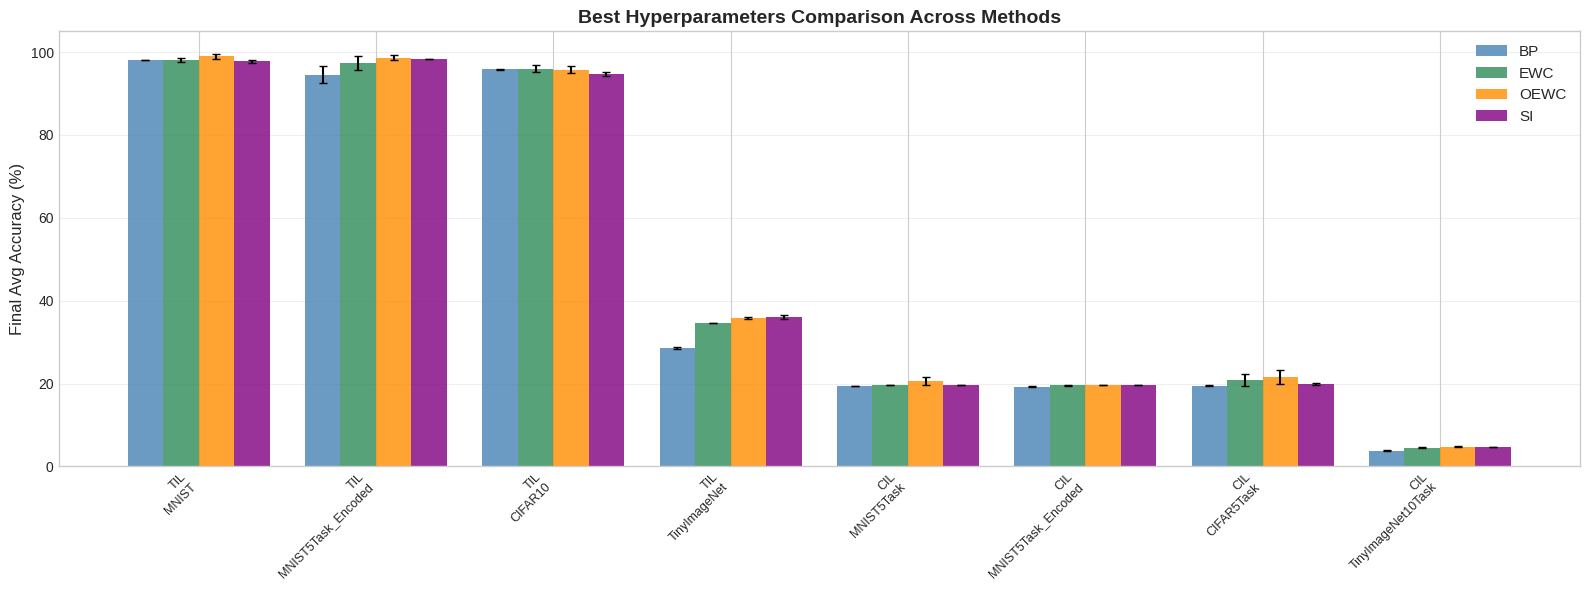

In [10]:
if len(best_results) > 0:
    # Get all settings that appear in any method
    all_settings = set()
    for best_df in best_results.values():
        all_settings.update(best_df['setting'].values)
    
    # Order settings
    setting_order = [
        "TaskILMNIST", "TaskILMNIST5Task_Encoded", "TaskILCIFAR10", "TaskILTinyImageNet",
        "ClassILMNIST5Task", "ClassILMNIST5Task_Encoded", "ClassILCIFAR5Task", "ClassILTinyImageNet10Task",
    ]
    plot_settings = [s for s in setting_order if s in all_settings]
    plot_settings += [s for s in all_settings if s not in setting_order]
    
    # Prepare data
    methods_with_data = [m for m in ['bp', 'ewc', 'oewc', 'si'] if m in best_results]
    n_methods = len(methods_with_data)
    n_settings = len(plot_settings)
    
    fig, ax = plt.subplots(figsize=(max(10, 2*n_settings), 6))
    
    x = np.arange(n_settings)
    width = 0.8 / n_methods
    colors = {'bp': 'steelblue', 'ewc': 'seagreen', 'oewc': 'darkorange', 'si': 'purple'}
    
    for i, method in enumerate(methods_with_data):
        means = []
        stds = []
        for setting in plot_settings:
            best_df = best_results[method]
            row = best_df[best_df['setting'] == setting]
            if len(row) > 0:
                means.append(row.iloc[0]['mean_acc'])
                stds.append(row.iloc[0]['std_acc'])
            else:
                means.append(0)
                stds.append(0)
        
        offset = (i - n_methods/2 + 0.5) * width
        bars = ax.bar(x + offset, means, width, yerr=stds, label=method.upper(),
                      capsize=3, color=colors.get(method, 'gray'), alpha=0.8)
    
    ax.set_ylabel('Final Avg Accuracy (%)', fontsize=12)
    ax.set_title('Best Hyperparameters Comparison Across Methods', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('ClassIL', 'CIL\n').replace('TaskIL', 'TIL\n') 
                        for s in plot_settings], fontsize=9, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    plt.savefig('all_methods_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No data available for comparison plot")

## 5. Hyperparameter Sensitivity Analysis

In [11]:
def plot_lr_sensitivity(df: pd.DataFrame, method: str, title_suffix: str = ""):
    """Plot learning rate sensitivity for a given method."""
    method_df = df[df['method'] == method]
    if len(method_df) == 0:
        print(f"No {method.upper()} data available")
        return
    
    settings = sorted(method_df['setting'].unique())
    n_settings = len(settings)
    
    if n_settings == 0:
        return
    
    n_cols = min(4, n_settings)
    n_rows = (n_settings + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_settings > 1 else [axes]
    
    for idx, setting in enumerate(settings):
        setting_df = method_df[method_df['setting'] == setting]
        lr_stats = setting_df.groupby('lr')['final_avg_accuracy'].agg(['mean', 'std']).reset_index()
        lr_stats = lr_stats.sort_values('lr')
        
        ax = axes[idx]
        ax.errorbar(range(len(lr_stats)), lr_stats['mean'], yerr=lr_stats['std'],
                    marker='o', capsize=5, capthick=2, linewidth=2, markersize=8)
        ax.set_xticks(range(len(lr_stats)))
        ax.set_xticklabels([f"{lr:.0e}" for lr in lr_stats['lr']], rotation=45)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Final Avg Accuracy (%)')
        ax.set_title(f'{setting}')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle(f'{method.upper()}: Learning Rate Sensitivity{title_suffix}', 
                 y=1.02, fontsize=14, fontweight='bold')
    plt.savefig(f'{method}_lr_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()

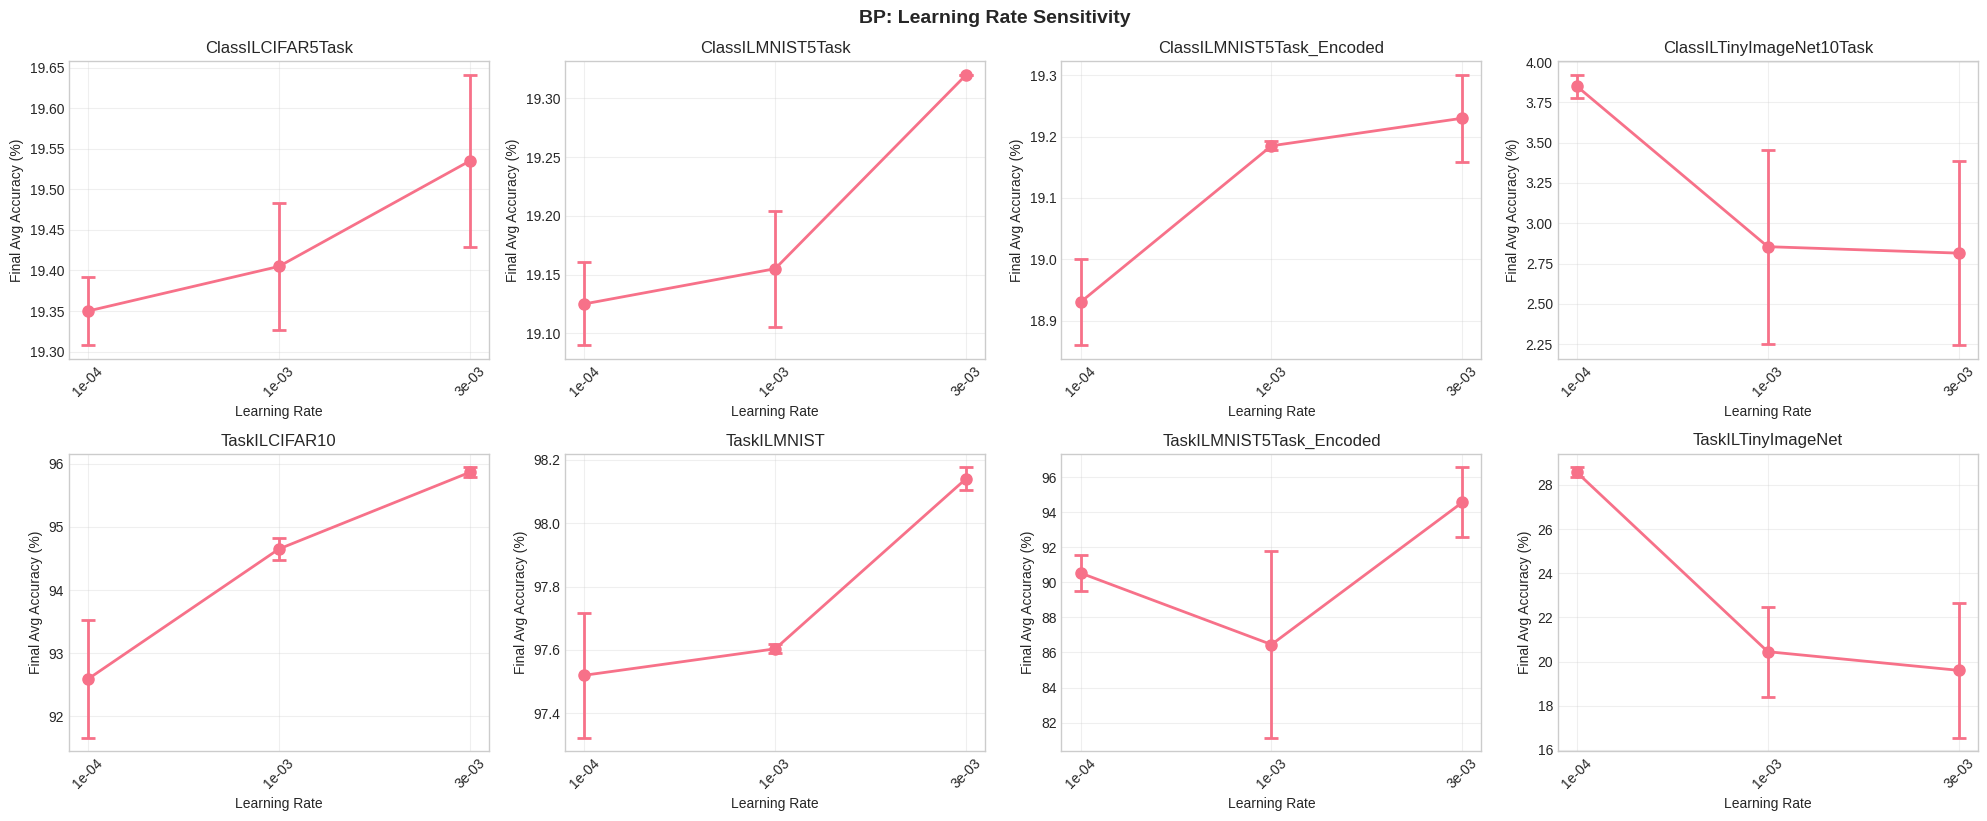

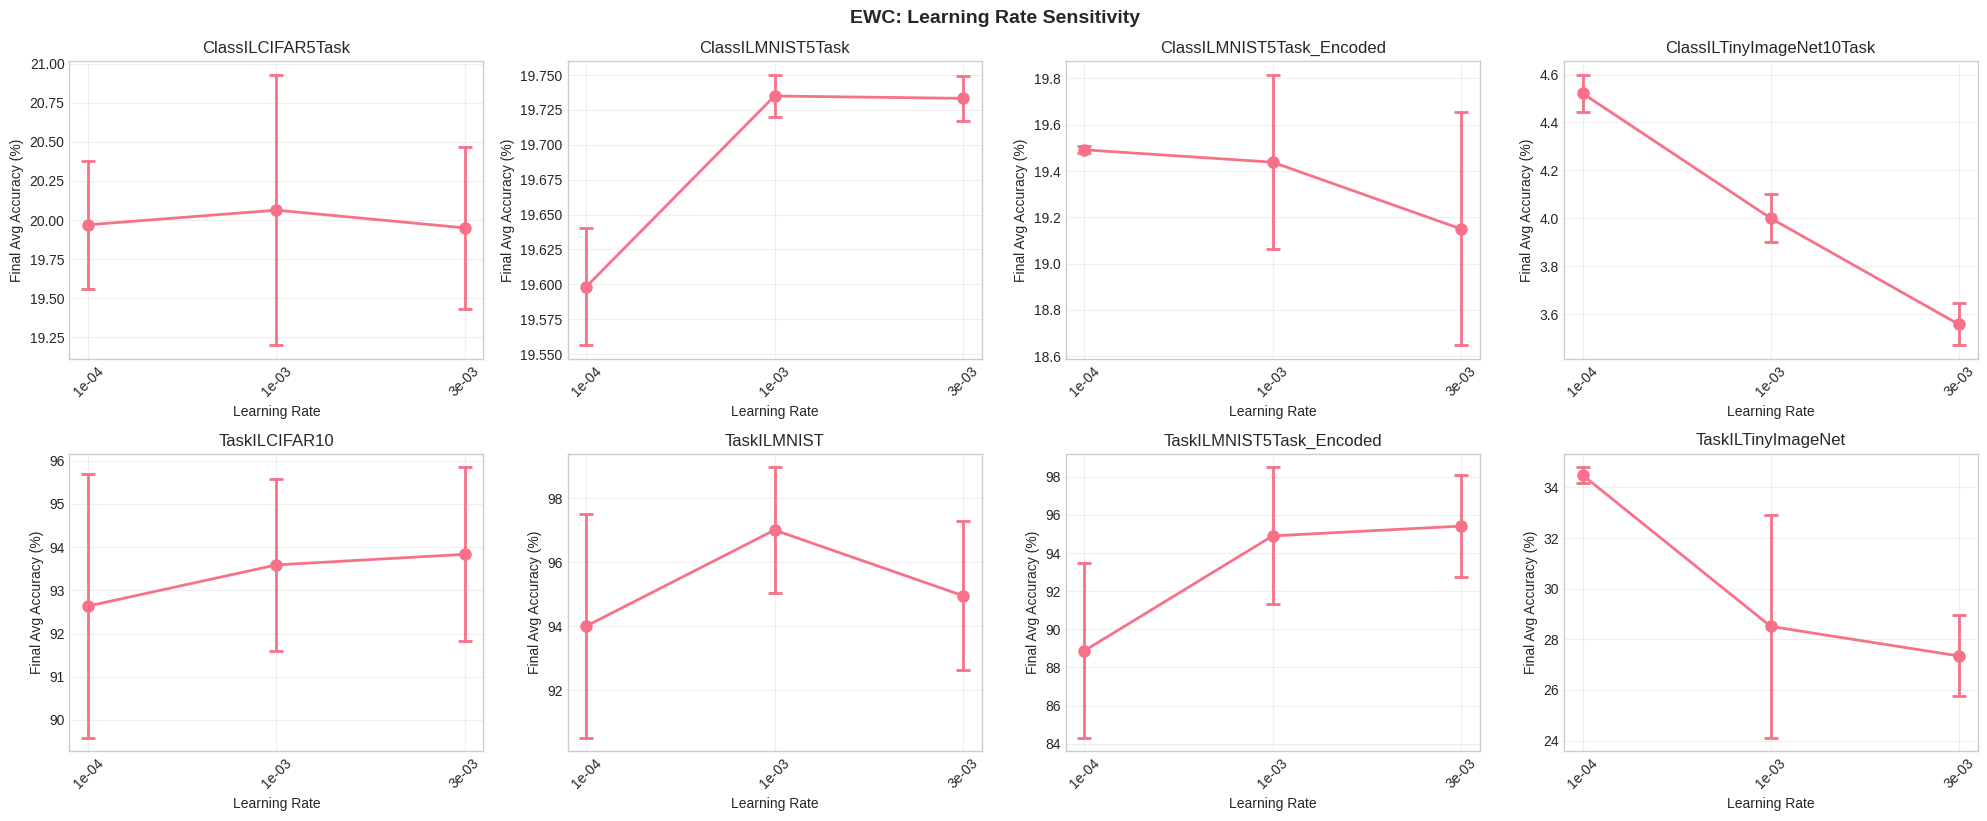

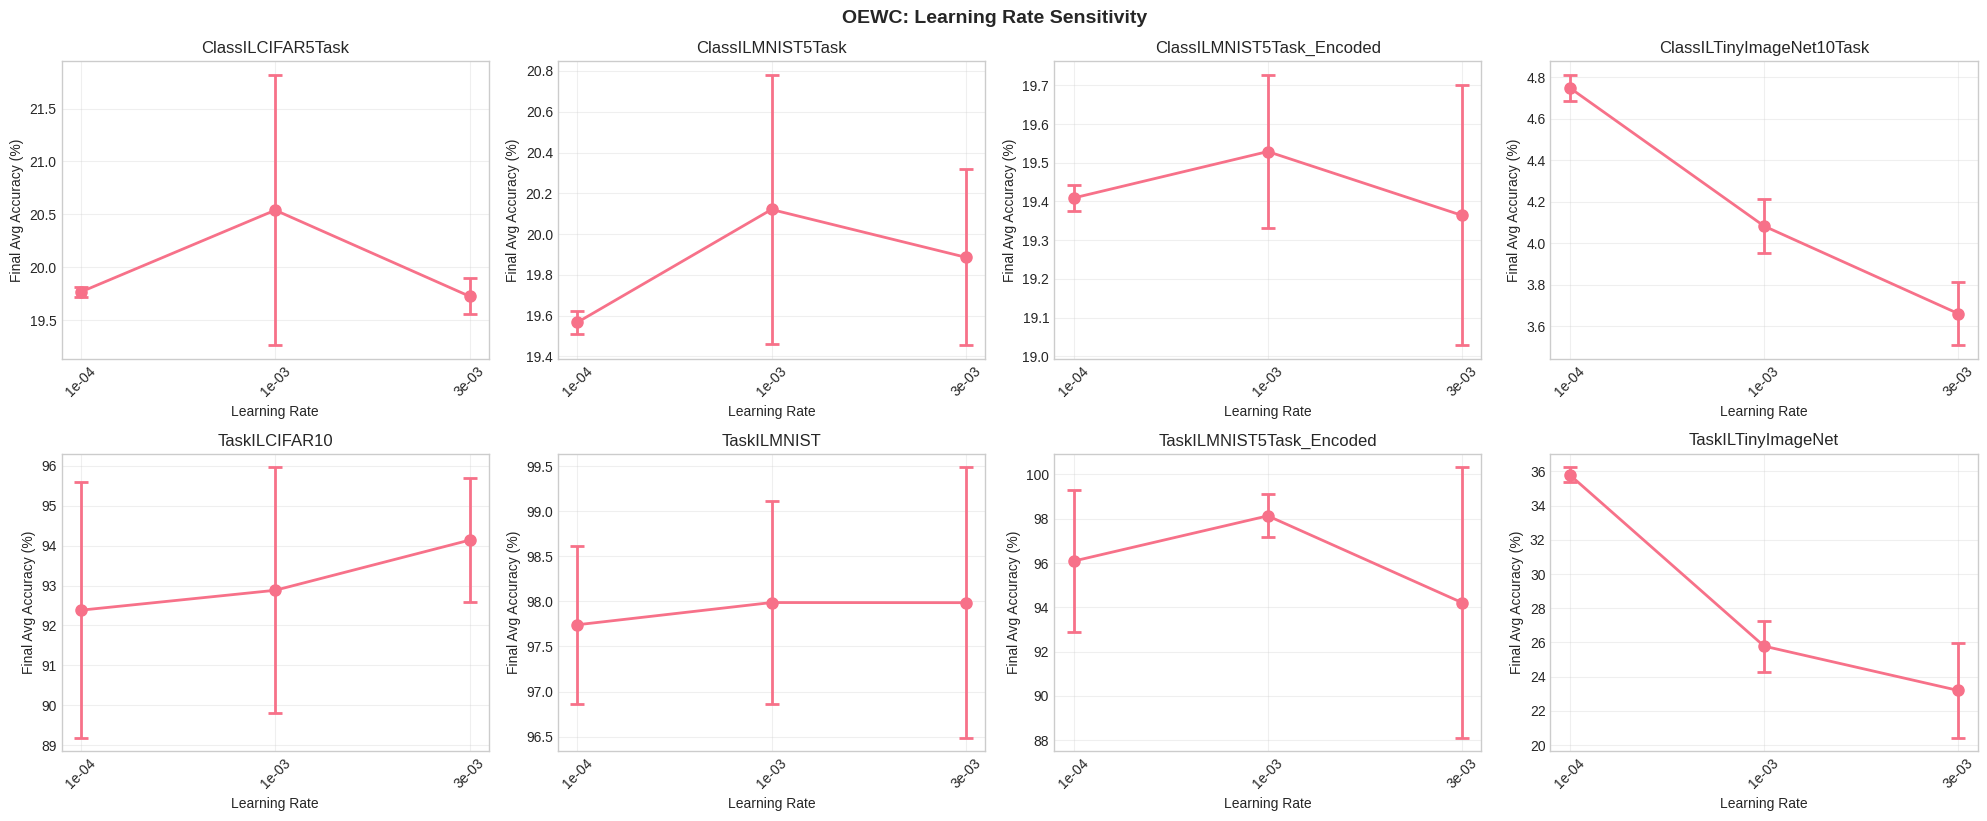

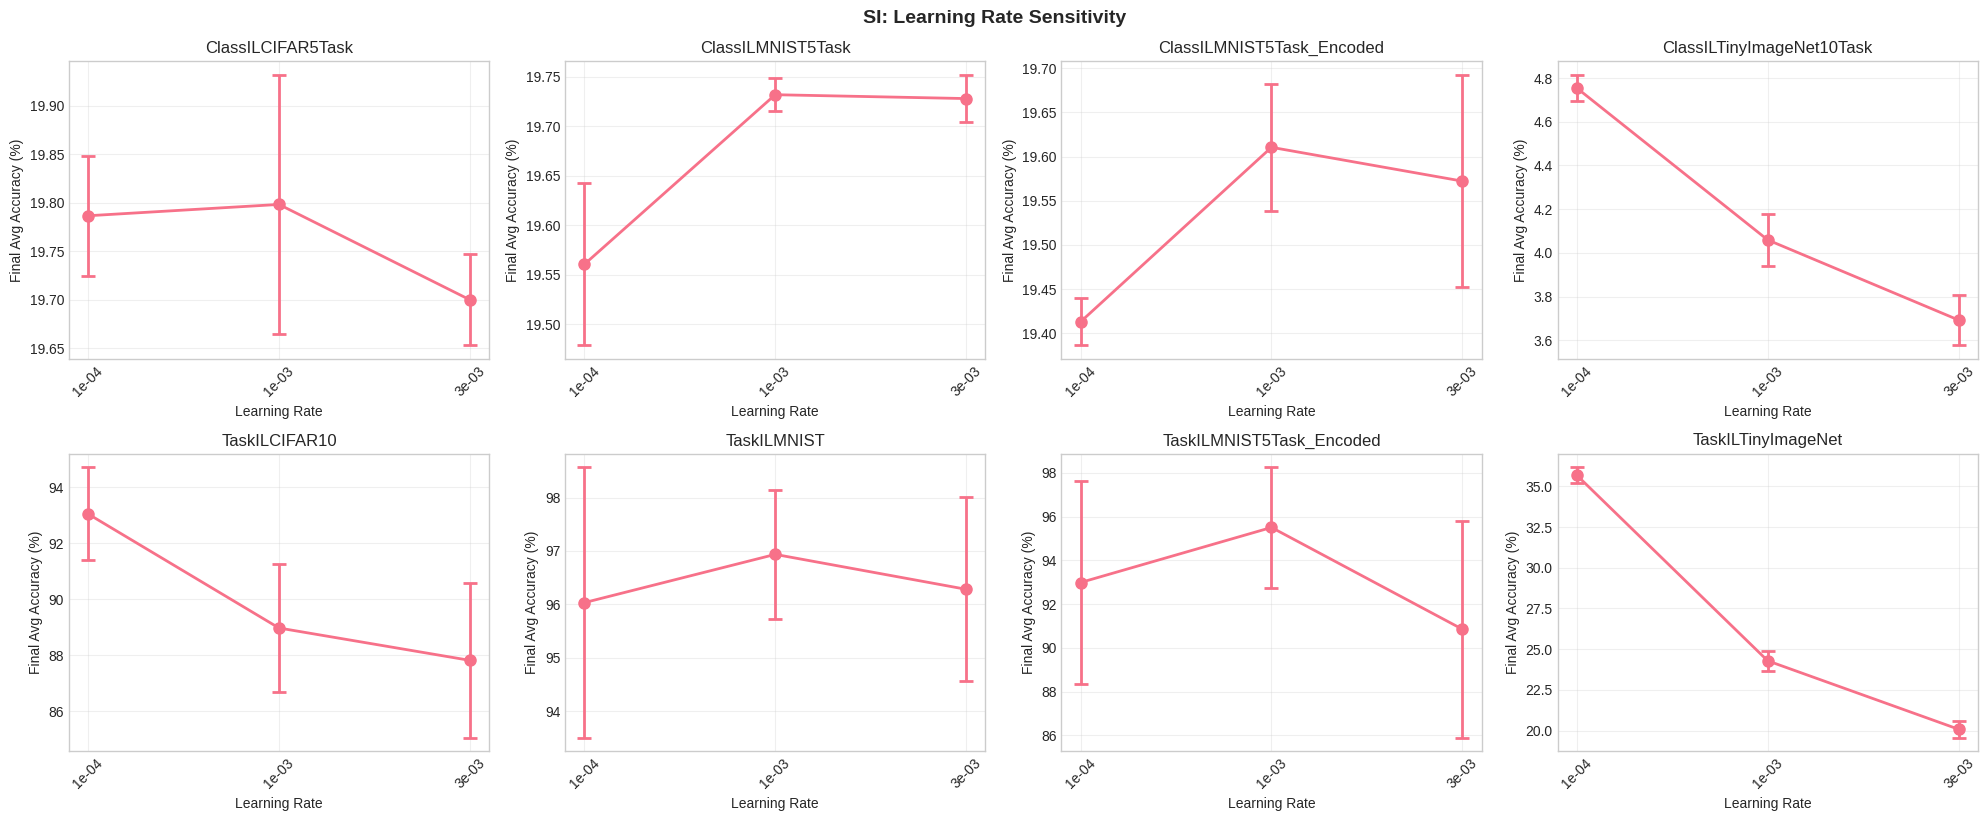

In [12]:
# Learning rate sensitivity for each method
if len(df) > 0:
    for method in ['bp', 'ewc', 'oewc', 'si']:
        if method in df['method'].values:
            plot_lr_sensitivity(df, method)

### Importance (λ) Sensitivity for EWC/oEWC/SI

In [13]:
def plot_importance_heatmap(df: pd.DataFrame, method: str):
    """Plot heatmap of lr vs importance_ewc for a given method."""
    method_df = df[df['method'] == method]
    if len(method_df) == 0 or 'importance_ewc' not in method_df.columns:
        print(f"No {method.upper()} importance data available")
        return
    
    settings = sorted(method_df['setting'].unique())
    n_settings = len(settings)
    
    if n_settings == 0:
        return
    
    n_cols = min(4, n_settings)
    n_rows = (n_settings + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_settings > 1 else [axes]
    
    for idx, setting in enumerate(settings):
        setting_df = method_df[method_df['setting'] == setting]
        
        pivot = setting_df.pivot_table(
            values='final_avg_accuracy',
            index='importance_ewc',
            columns='lr',
            aggfunc='mean'
        )
        
        pivot = pivot.sort_index(ascending=False)
        pivot = pivot[sorted(pivot.columns)]
        
        ax = axes[idx]
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
                    cbar_kws={'label': 'Accuracy (%)'})
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Importance (λ)')
        ax.set_title(f'{setting}')
    
    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle(f'{method.upper()}: Accuracy Heatmap (lr vs λ)', 
                 y=1.02, fontsize=14, fontweight='bold')
    plt.savefig(f'{method}_importance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

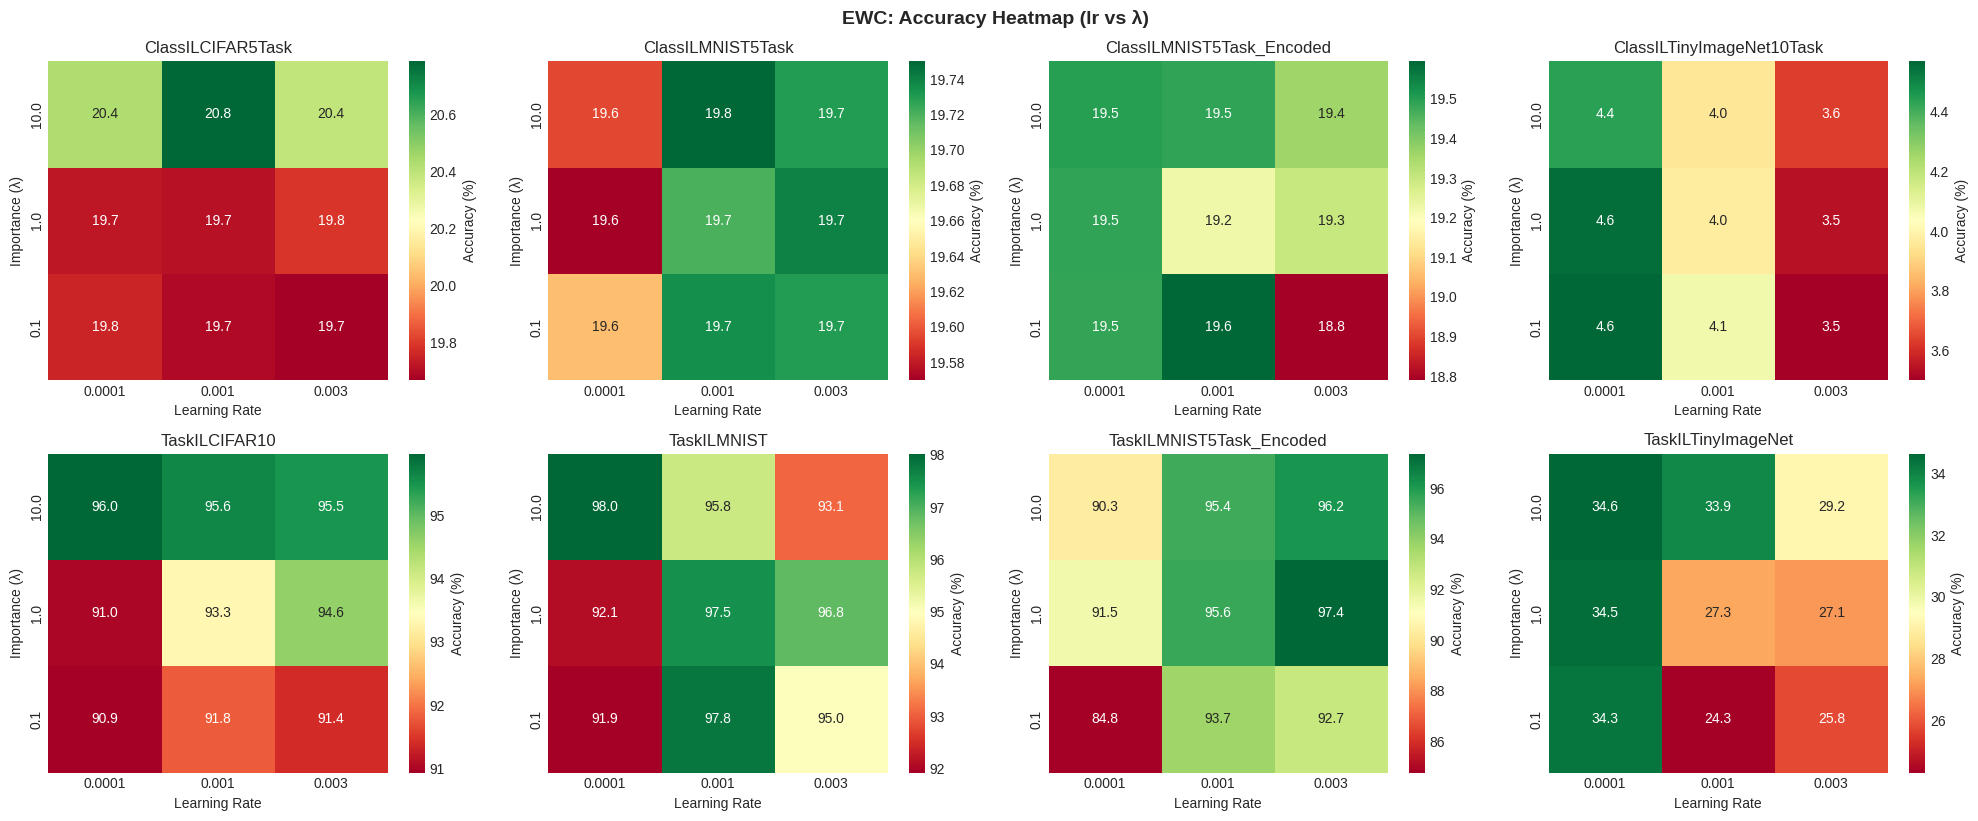

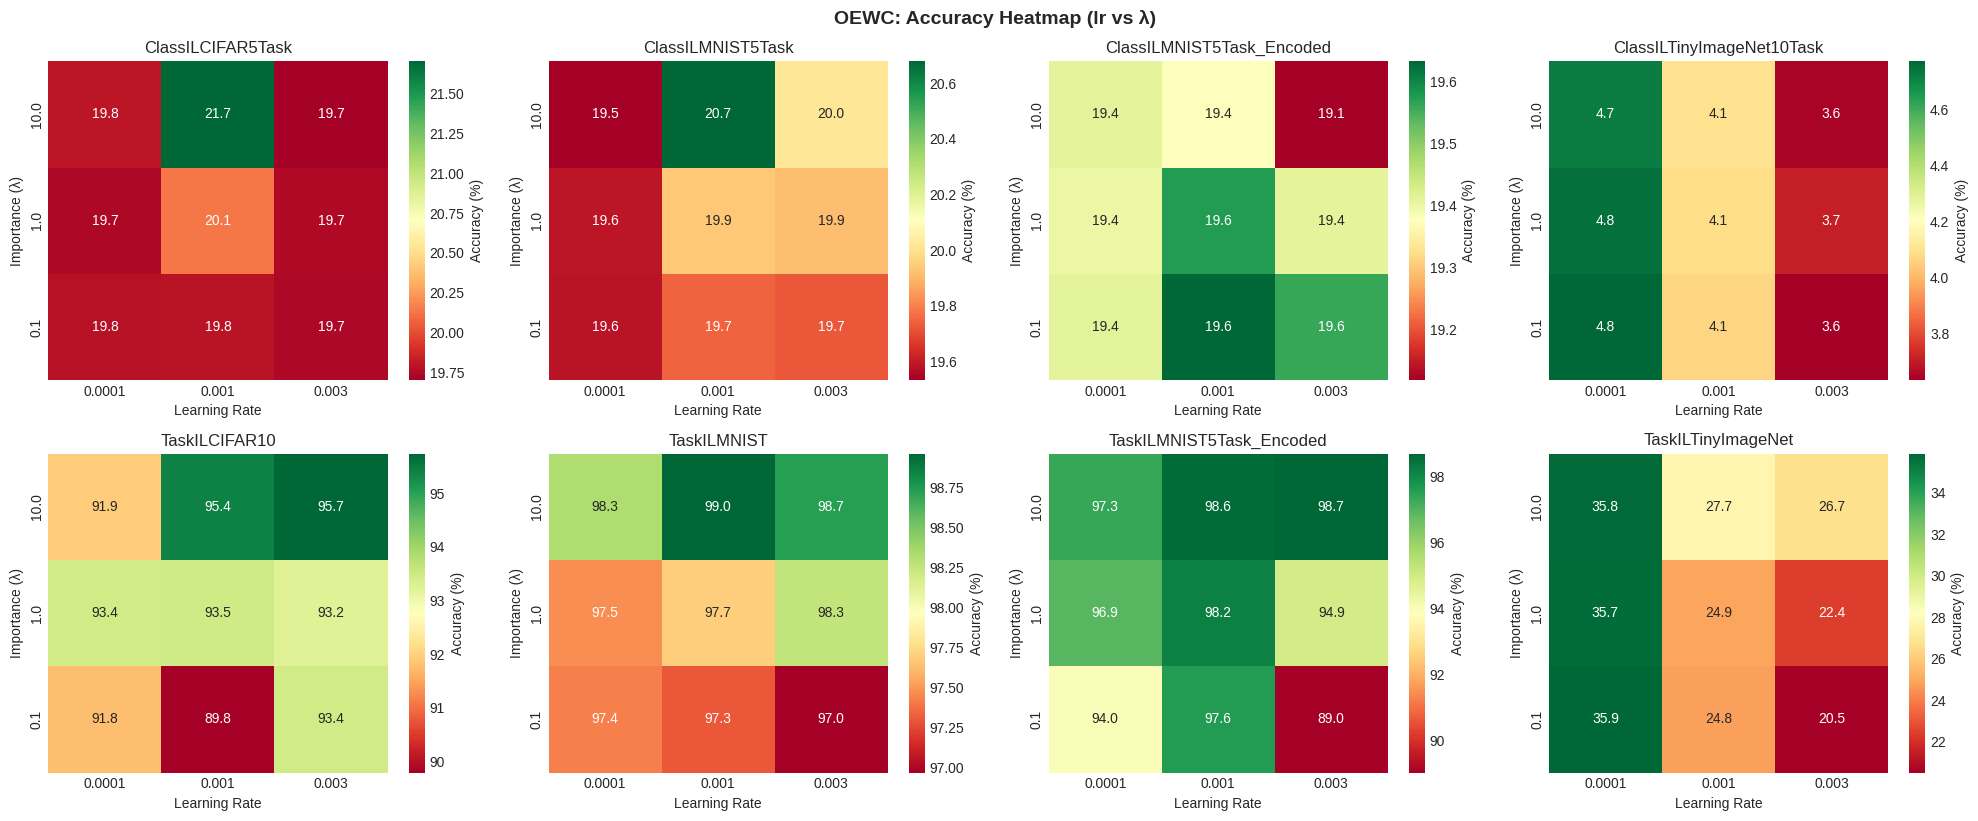

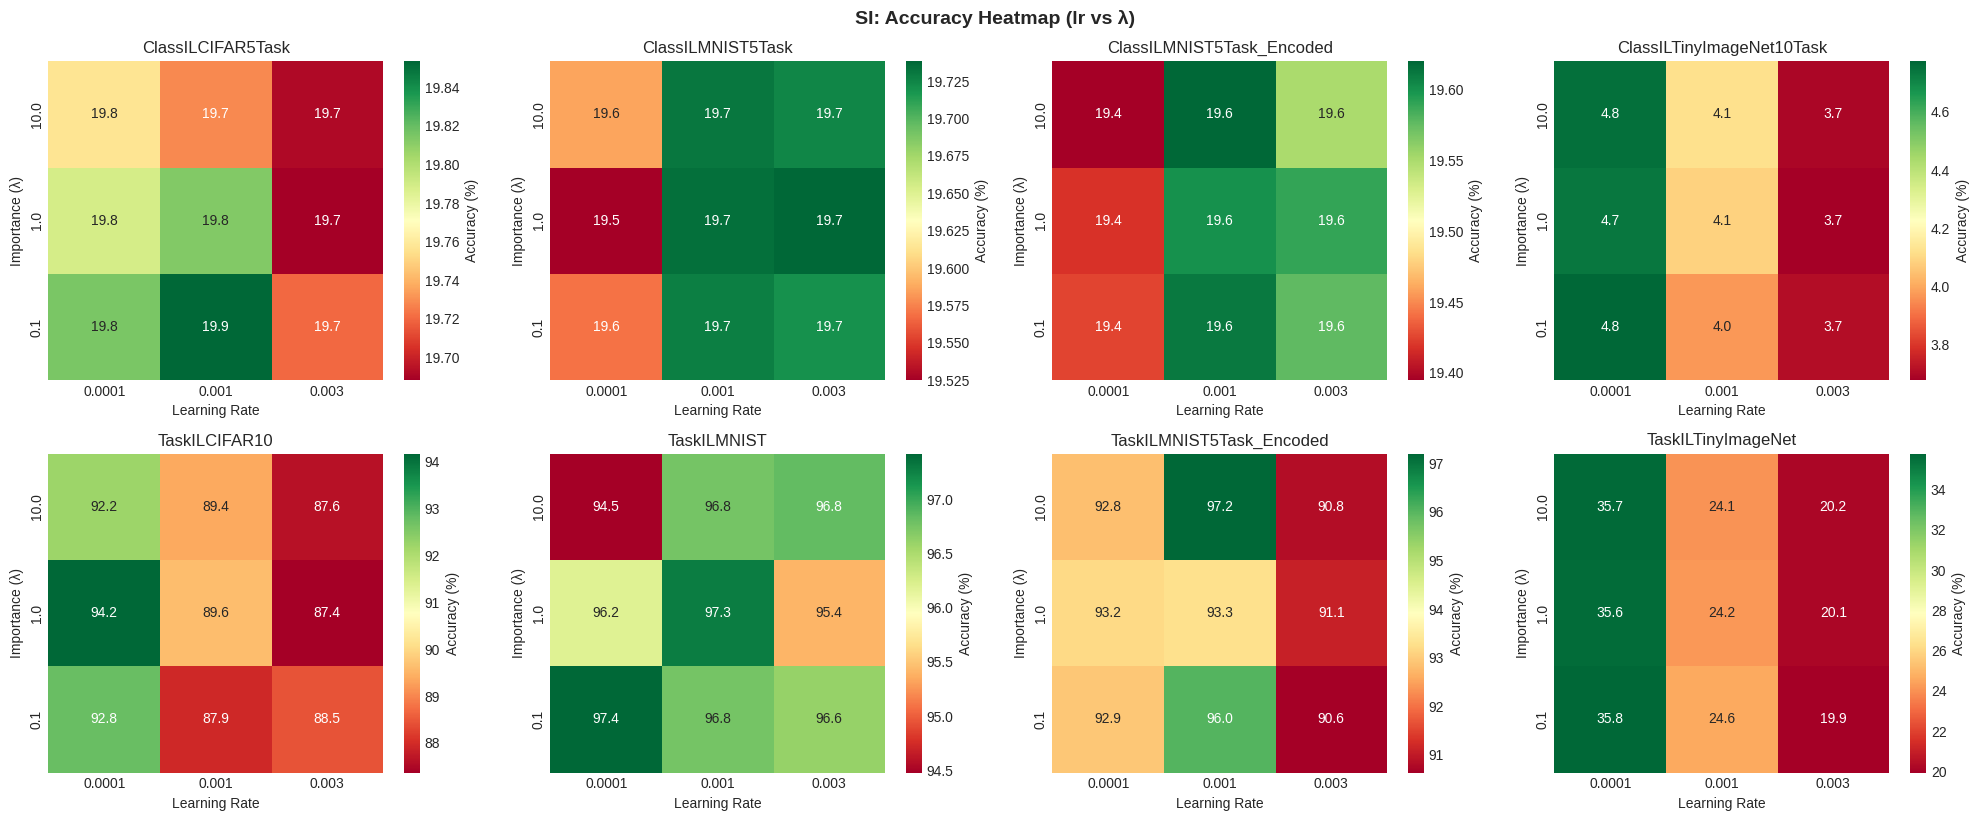

In [14]:
# Importance heatmaps for regularization methods
if len(df) > 0:
    for method in ['ewc', 'oewc', 'si']:
        if method in df['method'].values:
            plot_importance_heatmap(df, method)

### SI Damping (ξ) Sensitivity

In [ ]:
def plot_si_damping_sensitivity(df: pd.DataFrame):
    """Plot SI damping sensitivity."""
    si_df = df[df['method'] == 'si']
    if len(si_df) == 0 or 'si_damping' not in si_df.columns:
        print("No SI damping data available")
        return
    
    settings = sorted(si_df['setting'].unique())
    n_settings = len(settings)
    
    if n_settings == 0:
        return
    
    n_cols = min(4, n_settings)
    n_rows = (n_settings + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_settings > 1 else [axes]
    
    for idx, setting in enumerate(settings):
        setting_df = si_df[si_df['setting'] == setting]
        
        # Create pivot table: importance_ewc vs si_damping
        pivot = setting_df.pivot_table(
            values='final_avg_accuracy',
            index='importance_ewc',
            columns='si_damping',
            aggfunc='mean'
        )
        
        pivot = pivot.sort_index(ascending=False)
        pivot = pivot[sorted(pivot.columns)]
        
        ax = axes[idx]
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
                    cbar_kws={'label': 'Accuracy (%)'})
        ax.set_xlabel('SI Damping (ξ)')
        ax.set_ylabel('Importance (λ)')
        ax.set_title(f'{setting}')
    
    # Hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('SI: Accuracy Heatmap (λ vs ξ)', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('si_damping_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
if len(df) > 0 and 'si' in df['method'].values:
    plot_si_damping_sensitivity(df)

## 6. Top Configurations per Method and Setting

In [ ]:
def print_top_configs(df: pd.DataFrame, method: str, top_n: int = 5):
    """Print top N configurations for each setting."""
    method_df = df[df['method'] == method]
    if len(method_df) == 0:
        print(f"No {method.upper()} data available")
        return
    
    print("=" * 80)
    print(f"TOP {top_n} {method.upper()} CONFIGURATIONS PER SETTING")
    print("=" * 80)
    
    # Determine grouping columns based on method
    if method == 'bp':
        group_cols = ['lr']
    elif method in ['ewc', 'oewc']:
        group_cols = ['lr', 'importance_ewc']
    else:  # si
        group_cols = ['lr', 'importance_ewc', 'si_damping']
    
    for setting in sorted(method_df['setting'].unique()):
        setting_df = method_df[method_df['setting'] == setting]
        
        print(f"\n{'='*40}")
        print(f"Setting: {setting}")
        print(f"{'='*40}")
        
        grouped = setting_df.groupby(group_cols).agg({
            'final_avg_accuracy': ['mean', 'std', 'count']
        }).reset_index()
        grouped.columns = group_cols + ['mean_acc', 'std_acc', 'n_seeds']
        
        top = grouped.nlargest(top_n, 'mean_acc')
        print(top.to_string(index=False))

In [ ]:
if len(df) > 0:
    for method in ['bp', 'ewc', 'oewc', 'si']:
        if method in df['method'].values:
            print_top_configs(df, method)
            print("\n")

## 7. Export Results

In [ ]:
if len(df) > 0:
    # Save the full results dataframe
    df.to_csv('sweep_results_all_methods.csv', index=False)
    print("Saved full results to sweep_results_all_methods.csv")
    
    # Save best hyperparameters for each method
    for method, best_df in best_results.items():
        filename = f'best_hyperparams_{method}.csv'
        best_df.to_csv(filename, index=False)
        print(f"Saved best {method.upper()} hyperparameters to {filename}")
else:
    print("No data to export")

## 8. Paper-Ready Summary Table

In [ ]:
if len(best_results) > 0:
    print("\n" + "=" * 100)
    print("FINAL SUMMARY FOR PAPER (Markdown Format)")
    print("=" * 100)
    
    # Get all available methods and settings
    available_methods = [m for m in ['bp', 'ewc', 'oewc', 'si'] if m in best_results]
    
    all_settings = set()
    for best_df in best_results.values():
        all_settings.update(best_df['setting'].values)
    
    setting_order = [
        "TaskILMNIST", "TaskILMNIST5Task_Encoded", "TaskILCIFAR10", "TaskILTinyImageNet",
        "ClassILMNIST5Task", "ClassILMNIST5Task_Encoded", "ClassILCIFAR5Task", "ClassILTinyImageNet10Task",
    ]
    available_settings = [s for s in setting_order if s in all_settings]
    available_settings += [s for s in all_settings if s not in setting_order]
    
    # Print header
    header = "| Setting | " + " | ".join([m.upper() for m in available_methods]) + " |"
    separator = "|" + "|".join(["-" * (len(h) + 2) for h in header.split("|")[1:-1]]) + "|"
    
    print(header)
    print(separator)
    
    # Print rows
    for setting in available_settings:
        row_parts = [setting]
        for method in available_methods:
            if method in best_results:
                best_df = best_results[method]
                setting_row = best_df[best_df['setting'] == setting]
                if len(setting_row) > 0:
                    data = setting_row.iloc[0]
                    row_parts.append(f"{data['mean_acc']:.1f} ± {data['std_acc']:.1f}")
                else:
                    row_parts.append("-")
            else:
                row_parts.append("-")
        
        print("| " + " | ".join(row_parts) + " |")
    
    # Print best hyperparameters legend
    print("\n\n### Best Hyperparameters:")
    for method in available_methods:
        print(f"\n**{method.upper()}:**")
        best_df = best_results[method]
        for _, row in best_df.iterrows():
            params = [f"lr={row['lr']:.0e}"]
            if method in ['ewc', 'oewc', 'si'] and 'importance_ewc' in row:
                params.append(f"λ={row['importance_ewc']}")
            if method == 'si' and 'si_damping' in row:
                params.append(f"ξ={row['si_damping']}")
            print(f"- {row['setting']}: {', '.join(params)}")
else:
    print("No data available for paper summary")